# Preprocessing the complaints column

1. clean text
   - lowercase
   - remove punct/digits/special characeters
   - remove cfpb tokens XXXX
2. tokenize
3. stopwords removal
4. lemmatize

In [33]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import words
import spacy
import string

In [2]:
data = pd.read_csv('data/product_complaints.csv')
data.head()

,product,complaints
0,credit_reporting,NaN
1,credit_card,NaN
2,credit_reporting,These are not my accounts.
3,credit_reporting,Kindly address this issue on my credit report....
4,credit_reporting,NaN


In [3]:
data.isnull().sum()

product              0
complaints    11407901
dtype: int64

In [4]:
data = data.dropna(subset=['complaints'])
print(data.isnull().sum())
print(data.head())

product       0
complaints    0
dtype: int64
            product                                         complaints
2  credit_reporting                         These are not my accounts.
3  credit_reporting  Kindly address this issue on my credit report....
5  credit_reporting  I wrote three requests, the unverified account...
6  credit_reporting  XXXX XXXX has a old account settled in XXXX th...
7             loans  They call at all hours and on the weekends usi...


In [5]:
data['product'].value_counts()

product
credit_reporting    2508471
debt_collection      422840
retail_banking       314368
credit_card          236957
loans                155345
mortgage             142617
Name: count, dtype: int64

In [6]:
dfs = []
for cat in data['product'].unique():
    cat_df = data[data['product'] == cat]
    dfs.append(cat_df.sample(min(len(cat_df), 142617), random_state=42))

df_stratified = pd.concat(dfs).reset_index(drop=True)
print(df_stratified['product'].value_counts())

product
credit_reporting    142617
loans               142617
credit_card         142617
debt_collection     142617
retail_banking      142617
mortgage            142617
Name: count, dtype: int64


In [7]:
df_stratified.info()

<class 'pandas.DataFrame'>
RangeIndex: 855702 entries, 0 to 855701
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   product     855702 non-null  str  
 1   complaints  855702 non-null  str  
dtypes: str(2)
memory usage: 13.1 MB


In [ ]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.8 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


CompletedProcess(args=['/Users/minkhant/Downloads/Projects/Complaints Analysis/.venv/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

# 1. Clean Text

In [9]:
def clean_text(text: str) -> str:
    text = text.lower() # lowercase
    text = re.sub(r'\bx+\b', ' ', text) # standalone 'x'
    text = re.sub(r'\bx+\d+\b', ' ', text) # x followed by digits
    text = re.sub(r'x{2,}', ' ', text) # x fused with other characters
    text = re.sub(r'[^a-z\s]', ' ', text) # replace non-letters
    text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces
    return text    

In [10]:
sample = data.loc[100]["complaints"]
print(sample)
cleaned_sample = clean_text(sample)
print("----------------------------------")
print(cleaned_sample)

This is my first endeavor to tell you that I am a victim of identity theft and I complain to question specific records in my document coming about because of the wrongdoing. The records I am questioning connect with no exchanges acquiring any possession of goods, services or money that I have made or authorized. Assuming no one cares either way, block the noteworthy of any information in my credit record that came about due to an alleged fraud or extortion. 
XXXX XXXXXXXX XXXX XXXX XXXX XXXX XXXX, FL XXXX XXXX XXXXXXXX XXXX XXXX XXXXXXXX, FL XXXX XXXXXXXX XXXX XXXX XXXX XXXX XXXX XXXXXXXX XXXX, FL XXXX XXXX XXXX XXXX, FL XXXX XXXX XXXX XXXX, FL XXXX XXXX XXXX XXXX XXXX XXXXXXXX, FL XXXX XXXX XXXX XXXXXXXX XXXX XXXX  FL XXXX XXXX XXXX XXXX XXXX XXXX XXXXXXXX XXXX, FL XXXX XXXX XXXX XXXX Balance Owed : {$0.00} XXXX XXXX XXXX Balance Owed : {$7400.00} XXXX XXXX XXXX XXXX XXXX Balance Owed : {$0.00} XXXX XXXX Balance Owed : {$2800.00} XXXX XXXX XXXX  Balance Owed : {$370.00} XXXX XXXX XXXX

# 2. Remove Stopwords

In [11]:
#stopwords list
STOPWORDS = set(stopwords.words('english'))

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [21]:
def tokenize(text: str) -> list:
    return word_tokenize(text)

def remove_stopwords(tokens: list) -> list:
    return [token for token in tokens if token not in STOPWORDS]

def remove_short_words(tokens: list, min_length: int = 3) -> list:
    return [token for token in tokens if len(token) >= min_length]

# def lemmatize(tokens: list) -> list:
#     doc = nlp(' '.join(tokens))
#     return [token.lemma_ for token in doc if not token.is_stop and len(token.lemma_) >= 3 and token.lemma_.isalpha()]

In [23]:
from tqdm import tqdm

def preprocess_batch(texts: str) -> list:
    tokens_list = []
    cleaned = [clean_text(text) for text in texts]
    tokenized = [tokenize(text) for text in cleaned]
    no_stopwords = [remove_stopwords(tokens) for tokens in tokenized]
    no_short = [remove_short_words(tokens) for tokens in no_stopwords]
    for doc in tqdm(nlp.pipe([' '.join(t) for t in no_short],
                             batch_size=500, disable=['parser', 'ner']), total=len(texts)):
        tokens = [
            token.lemma_
            for token in doc
            if len(token.lemma_) >= 3 and token.lemma_.isalpha()
        ]
        tokens_list.append(tokens)
    return tokens_list

In [24]:
sample = df_stratified.loc[100]["complaints"]
print(sample)
cleaned_sample = clean_text(sample)
tokenized_sample = preprocess_batch([cleaned_sample])
print("----------------------------------")
print(tokenized_sample)

I XXXX XXXX contacted TransUnion on XX/XX/2021, I spoke to multiple employees as well as supervisors, regarding the fraudulent, inaccurate reporting on my credit report. Transunion knowingly and willingly broke the law regarding the written consent that I did not authorize. Nor did I give TransUnion the authority to furnish ANYTHING on my credit report, it is a direct violation of 15USC 1682 ( b ).

Pursuant to 15 U.S. Code 1681 ( n ) Transunion willfully failed to comply with the requirements imposed within the chapter and is civically liable for knowing noncompliance.


100%|██████████| 1/1 [00:00<00:00, 158.53it/s]

----------------------------------
[['contact', 'transunion', 'speak', 'multiple', 'employee', 'well', 'supervisor', 'regard', 'fraudulent', 'inaccurate', 'reporting', 'credit', 'report', 'transunion', 'knowingly', 'willingly', 'break', 'law', 'regard', 'write', 'consent', 'authorize', 'give', 'transunion', 'authority', 'furnish', 'anything', 'credit', 'report', 'direct', 'violation', 'usc', 'pursuant', 'code', 'transunion', 'willfully', 'fail', 'comply', 'requirement', 'impose', 'within', 'chapter', 'civically', 'liable', 'know', 'noncompliance']]


In [25]:
df_stratified['tokens'] = preprocess_batch(df_stratified['complaints'])

100%|██████████| 855702/855702 [4:18:06<00:00, 55.25it/s]     


In [26]:
df_stratified.head()

,product,complaints,tokens
0,credit_reporting,I have reviewed my credit report and noticed i...,"[review, credit, report, notice, incorrect, in..."
1,credit_reporting,"Seriously, it's been months since I investigat...","[seriously, month, since, investigate, credit,..."
2,credit_reporting,SS # XXXX birthday XX/XX/year> This CFPB compl...,"[birthday, year, cfpb, complaint, fill, reques..."
3,credit_reporting,"Upon reviewing my credit report, I have identi...","[upon, review, credit, report, identify, inacc..."
4,credit_reporting,They are a predatory lenders who are intention...,"[predatory, lender, intentionally, report, err..."


In [ ]:
# import ssl
# try:
#     _create_unverified_https_context = ssl._create_unverified_context
# except AttributeError:
#     pass
# else:
#     ssl._create_default_https_context = _create_unverified_https_context

In [ ]:
# nltk.download('words')

[nltk_data] Downloading package words to /Users/minkhant/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [38]:
english_words = set(words.words())

def filter_english(tokens):
    return [token for token in tokens if token in english_words]

df_stratified['tokens'] = df_stratified['tokens'].apply(filter_english)

In [39]:
df_stratified['tokens_str'] = df_stratified['tokens'].apply(lambda x: ' '.join(x))

In [40]:
df_stratified.to_pickle('data/tokens.pkl')

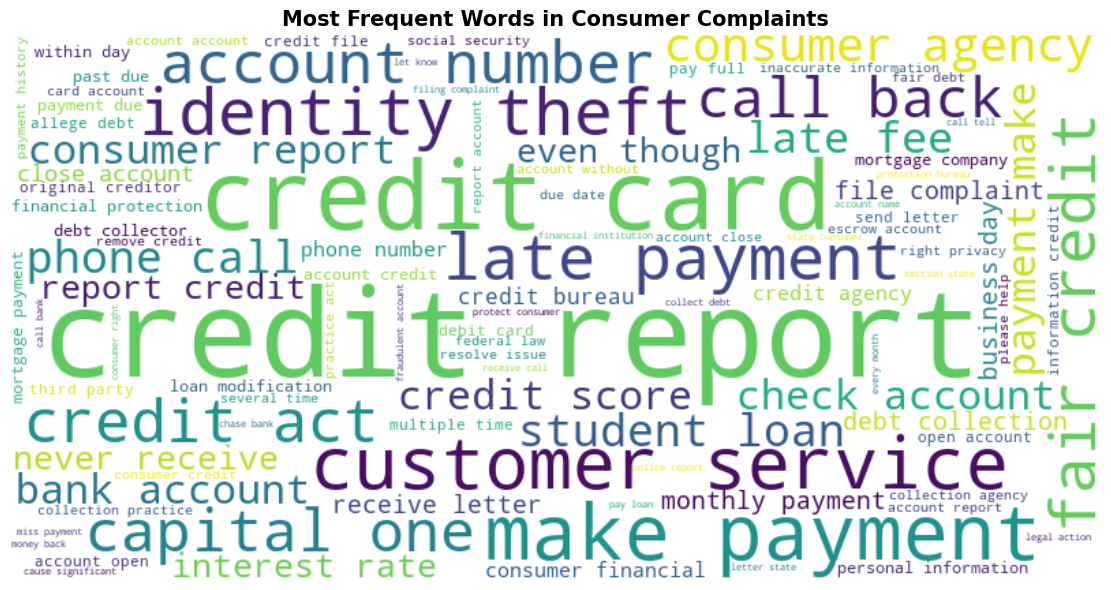

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df_stratified['tokens_str'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Consumer Complaints", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("overall_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
